In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# from google.colab import files
# uploaded = files.upload()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Crop Yield Prediction
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load dataset
data = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/Crop Prediction dataset.csv")

data['Yield'] = (data['Production'] / data['Area'])
data.head(10)


,State_Name,District_Name,Crop_Year,Season,Crop,Temperature,Humidity,Soil_Moisture,Area,Production,Yield
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,36,35,45,1254.0,2000.0,1.594896
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,37,40,46,2.0,1.0,0.500000
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,36,41,50,102.0,321.0,3.147059
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,37,42,55,176.0,641.0,3.642045
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,36,40,54,720.0,165.0,0.229167
5,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Coconut,34,45,52,18168.0,65100000.0,3583.223250
6,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Dry ginger,34,55,62,36.0,100.0,2.777778
7,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Sugarcane,35,50,59,1.0,2.0,2.000000
8,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Sweet potato,25,55,55,5.0,15.0,3.000000
9,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Tapioca,36,35,45,40.0,169.0,4.225000


In [ ]:
data.isnull().sum()

,0
State_Name,0
District_Name,0
Crop_Year,0
Season,0
Crop,0
Temperature,0
Humidity,0
Soil_Moisture,0
Area,0
Production,215


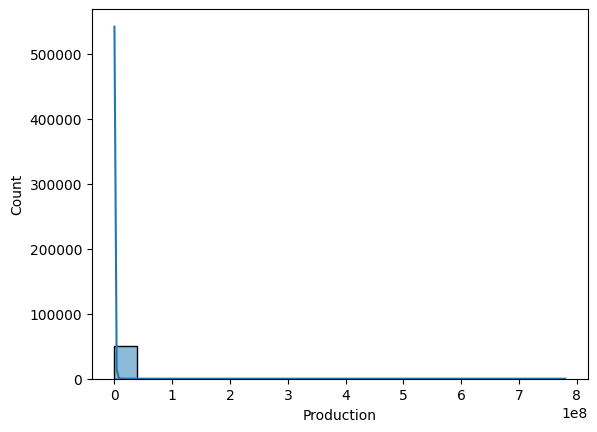

In [ ]:
sns.histplot(data['Production'],bins=20,kde=True)
plt.show()

In [ ]:
data['Production'] = data['Production'].fillna(data['Production'].mean())
data

,State_Name,District_Name,Crop_Year,Season,Crop,Temperature,Humidity,Soil_Moisture,Area,Production,Yield
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,36,35,45,1254.0,2000.0,1.594896
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,37,40,46,2.0,1.0,0.500000
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,36,41,50,102.0,321.0,3.147059
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,37,42,55,176.0,641.0,3.642045
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,36,40,54,720.0,165.0,0.229167
...,...,...,...,...,...,...,...,...,...,...,...
49994,Chhattisgarh,JANJGIR-CHAMPA,2006,Kharif,Small millets,36,35,45,27.0,7.0,0.259259
49995,Chhattisgarh,JANJGIR-CHAMPA,2006,Kharif,Soyabean,37,40,46,27.0,32.0,1.185185
49996,Chhattisgarh,JANJGIR-CHAMPA,2006,Kharif,Sunflower,36,41,50,450.0,213.0,0.473333
49997,Chhattisgarh,JANJGIR-CHAMPA,2006,Kharif,Urad,37,42,55,1778.0,309.0,0.173791


In [ ]:
data['Season']

,Season
0,Kharif
1,Kharif
2,Kharif
3,Whole Year
4,Whole Year
...,...
49994,Kharif
49995,Kharif
49996,Kharif
49997,Kharif


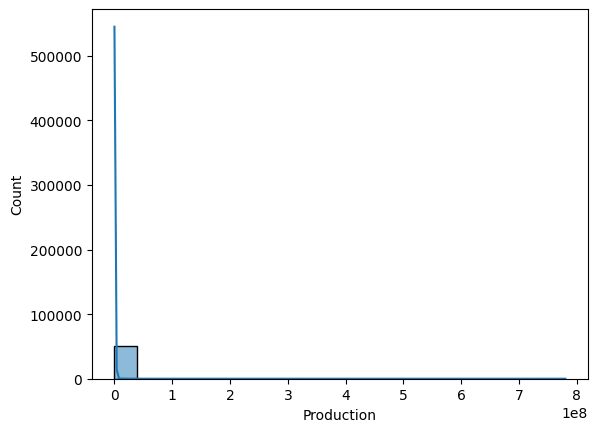

In [ ]:
sns.histplot(data['Production'],bins=20,kde=True)
plt.show()

In [ ]:
data['Yield'] = data['Yield'].fillna(data['Yield'].mean())
data

,State_Name,District_Name,Crop_Year,Season,Crop,Temperature,Humidity,Soil_Moisture,Area,Production,Yield
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,36,35,45,1254.0,2000.0,1.594896
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,37,40,46,2.0,1.0,0.500000
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,36,41,50,102.0,321.0,3.147059
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,37,42,55,176.0,641.0,3.642045
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,36,40,54,720.0,165.0,0.229167
...,...,...,...,...,...,...,...,...,...,...,...
49994,Chhattisgarh,JANJGIR-CHAMPA,2006,Kharif,Small millets,36,35,45,27.0,7.0,0.259259
49995,Chhattisgarh,JANJGIR-CHAMPA,2006,Kharif,Soyabean,37,40,46,27.0,32.0,1.185185
49996,Chhattisgarh,JANJGIR-CHAMPA,2006,Kharif,Sunflower,36,41,50,450.0,213.0,0.473333
49997,Chhattisgarh,JANJGIR-CHAMPA,2006,Kharif,Urad,37,42,55,1778.0,309.0,0.173791


In [ ]:
data.isnull().values.any()

np.False_

In [ ]:
unique_crops = data["Crop"].unique()

print(unique_crops)

['Arecanut' 'Other Kharif pulses' 'Rice' 'Banana' 'Cashewnut' 'Coconut '
 'Dry ginger' 'Sugarcane' 'Sweet potato' 'Tapioca' 'Black pepper'
 'Dry chillies' 'other oilseeds' 'Turmeric' 'Maize' 'Moong(Green Gram)'
 'Urad' 'Arhar/Tur' 'Groundnut' 'Sunflower' 'Bajra' 'Castor seed'
 'Cotton(lint)' 'Horse-gram' 'Jowar' 'Korra' 'Ragi' 'Tobacco' 'Gram'
 'Wheat' 'Masoor' 'Sesamum' 'Linseed' 'Safflower' 'Onion'
 'other misc. pulses' 'Samai' 'Small millets' 'Coriander' 'Potato'
 'Other  Rabi pulses' 'Soyabean' 'Beans & Mutter(Vegetable)' 'Bhindi'
 'Brinjal' 'Citrus Fruit' 'Cucumber' 'Grapes' 'Mango' 'Orange'
 'other fibres' 'Other Fresh Fruits' 'Other Vegetables' 'Papaya'
 'Pome Fruit' 'Tomato' 'Rapeseed &Mustard' 'Mesta' 'Cowpea(Lobia)' 'Lemon'
 'Pome Granet' 'Sapota' 'Cabbage' 'Peas  (vegetable)' 'Niger seed'
 'Bottle Gourd' 'Sannhamp' 'Varagu' 'Garlic' 'Ginger' 'Oilseeds total'
 'Pulses total' 'Jute' 'Peas & beans (Pulses)' 'Blackgram' 'Paddy'
 'Pineapple' 'Barley' 'Khesari' 'Guar seed']


In [ ]:
# Features & target
# Features & target
X = data[["Temperature","Humidity","Soil_Moisture","Area","Production"]]
y = data["Yield"]

In [ ]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Model
# model = RandomForestRegressor(n_estimators=100, random_state=42)
# model.fit(X_train, y_train)

In [ ]:
#underfitting
from sklearn.tree import DecisionTreeRegressor

underfit_model = DecisionTreeRegressor(max_depth=2, random_state=42)
underfit_model.fit(X_train, y_train)

y_train_pred = underfit_model.predict(X_train)
y_test_pred = underfit_model.predict(X_test)

print("UNDERFITTING MODEL")
print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2:", r2_score(y_test, y_test_pred))

UNDERFITTING MODEL
Train R2: 0.6872721727295943
Test R2: 0.6263797227893051


In [ ]:
#Overfitting
overfit_model = DecisionTreeRegressor(max_depth=None, random_state=42)
overfit_model.fit(X_train, y_train)

y_train_pred = overfit_model.predict(X_train)
y_test_pred = overfit_model.predict(X_test)

print("\nOVERFITTING MODEL")
print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2:", r2_score(y_test, y_test_pred))


OVERFITTING MODEL
Train R2: 1.0
Test R2: 0.9409961996047767


In [ ]:
#Balanced Model
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

# print("\nGOOD MODEL")
# print("Train R2:", r2_score(y_train, y_train_pred))
# print("Test R2:", r2_score(y_test, y_pred))
# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 10.905339546864795
R2 Score: 0.9449972483572767


In [ ]:
# # Predictions
# y_pred = model.predict(X_test)

# Evaluation
# print("MAE:", mean_absolute_error(y_test, y_pred))
# print("R2 Score:", r2_score(y_test, y_pred))

In [ ]:

# Predict new data
sample = [[200, 25, 70, 6.5, 2]]  # rainfall, temp, humidity, pH, area
prediction = model.predict(sample)
print("Predicted Yield:", prediction[0])

Predicted Yield: 1.921938449698323


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
# from google.colab import files
# uploaded = files.upload()

In [ ]:
# Soil Classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import r2_score

# Load dataset
data1= pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/data_core.csv")
data1.head(10)

,Temparature,Humidity,Moisture,Soil_Type,Crop_Type,Nitrogen,Potassium,Phosphorous,Fertilizer_Name
0,26.0,52.0,38.0,Sandy,Maize,37,0,0,Urea
1,29.0,52.0,45.0,Loamy,Sugarcane,12,0,36,DAP
2,34.0,65.0,62.0,Black,Cotton,7,9,30,14-35-14
3,32.0,62.0,34.0,Red,Tobacco,22,0,20,28-28
4,28.0,54.0,46.0,Clayey,Paddy,35,0,0,Urea
5,26.0,52.0,35.0,Sandy,Barley,12,10,13,17-17-17
6,25.0,50.0,64.0,Red,Cotton,9,0,10,20-20
7,33.0,64.0,50.0,Loamy,Wheat,41,0,0,Urea
8,30.0,60.0,42.0,Sandy,Millets,21,0,18,28-28
9,29.0,58.0,33.0,Black,Oil seeds,9,7,30,14-35-14


In [ ]:
data1.isnull().sum()

,0
Temparature,0
Humidity,0
Moisture,0
Soil_Type,0
Crop_Type,0
Nitrogen,0
Potassium,0
Phosphorous,0
Fertilizer_Name,0


In [ ]:
X = data1[["Nitrogen","Potassium", "Phosphorous","Temparature","Humidity","Moisture"]]
y = data1["Soil_Type"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model1 = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)

# model1 = RandomForestClassifier(
#     n_estimators=200,
#     max_depth=2,
#     random_state=42
# )
model1.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=500,
                       random_state=42)

In [ ]:

y_pred1 = model1.predict(X_test)

In [ ]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred1))
print(classification_report(y_test, y_pred1))

# Predict new sample
sample = [[90, 40, 40, 6.8, 30,46]]
prediction = model1.predict(sample)
print("Predicted Soil Type:", prediction[0])

Accuracy: 0.204375
              precision    recall  f1-score   support

       Black       0.22      0.23      0.22       323
      Clayey       0.21      0.22      0.21       324
       Loamy       0.20      0.20      0.20       318
         Red       0.21      0.19      0.20       319
       Sandy       0.20      0.19      0.19       316

    accuracy                           0.20      1600
   macro avg       0.20      0.20      0.20      1600
weighted avg       0.20      0.20      0.20      1600

Predicted Soil Type: Black


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 40.0 MB/s eta 0:00:00


In [ ]:
!pip install streamlit pyngrok

In [ ]:
# with open("iris_model.pkl",'wb')as f:
#     pickle.dump(model,f)

In [ ]:
%%writefile app1.py
import streamlit as st
from pyngrok import ngrok
import pickle
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

with open("iris_model.pkl", "rb") as f:
    models = pickle.load(f)

models1 = models["model1"]

#writing app
st.title("Crop Classification")
st.sidebar.header("Features")
def user_input():
    temperature = st.sidebar.slider("Temperature", 0.0, 50.0, 25.0)
    humidity = st.sidebar.slider("Humidity", 0.0, 100.0, 60.0)
    soil_moisture = st.sidebar.slider("Soil_Moisture", 0.0, 100.0, 50.0)
    area = st.sidebar.slider("Area", 0.0, 50.0, 25.0)
    production = st.sidebar.slider("Production", 0.0, 50.0, 25.0)

    data = {
        "Temperature": temperature,
        "Humidity": humidity,
        "Soil_Moisture": soil_moisture,
        "Area": area,
        "Production": production
    }

    return pd.DataFrame(data, index=[0])
# Get input
user_input_df1= user_input()

# Show input
st.subheader("User Input Parameters")
st.write(user_input_df1)

# Prediction
prediction= models1.predict(user_input_df1)
# Show results

st.subheader("Predicted Yield")
st.success(round(prediction[0], 2))

crop_name = label_encoder.inverse_transform(prediction)
st.subheader("Recommended Crop")
st.success(crop_name[0])


Overwriting app1.py


In [ ]:
!pkill -f streamlit

In [ ]:
!rm -rf ~/.ngrok2

In [ ]:
from pyngrok import ngrok
ngrok.kill()

In [ ]:
!streamlit run app1.py &>/content/logs.txt &

In [ ]:
!ngrok config add-authtoken 3CoKjzfRjH2choo01bQpuhv3bwy_4SSYjkCCfu5M6RzXjjuby

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://plunging-fantasize-unworried.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
%%writefile app2.py
import streamlit as st
from pyngrok import ngrok
import pickle
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

with open("iris_model.pkl", "rb") as f:
    models = pickle.load(f)

models2 = models["model2"]

#writing app
st.title("Soil Classification")
st.sidebar.header("Features")
def user_input():
    nitrogen = st.sidebar.slider("Nitrogen", 0, 140, 50)
    potassium = st.sidebar.slider("Potassium", 0, 140, 50)
    phosphorous = st.sidebar.slider("Phosphorous", 0, 140, 50)
    temperature = st.sidebar.slider("Temperature", 0.0, 50.0, 25.0)
    humidity = st.sidebar.slider("Humidity", 0.0, 100.0, 60.0)
    moisture = st.sidebar.slider("Moisture", 0.0, 100.0, 50.0)

    data = {
        "Nitrogen": nitrogen,
        "Potassium": potassium,
        "Phosphorous": phosphorous,
        "Temparature": temperature,
        "Humidity": humidity,
        "Moisture": moisture
    }

    return pd.DataFrame(data, index=[0])
# Get input
user_input_df = user_input()

# Show input
st.subheader("User Input Parameters")
st.write(user_input_df)

# Prediction
prediction1 = models2.predict(user_input_df)
prediction_proba1 = models2.predict_proba(user_input_df)
# Show results
st.subheader("Prediction")
st.write(prediction1[0])

st.subheader("Prediction Probability")
st.write(pd.DataFrame(prediction_proba1))
# Load dataset
data1= pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/data_core.csv")
#chart
st.subheader("Actual vs Predicted")
X = data1[["Nitrogen","Potassium", "Phosphorous","Temparature","Humidity","Moisture"]]
y = data1["Soil_Type"]
y_pred1= models2.predict(X)
# Comparison DataFrame
compare1 = pd.DataFrame({
    "Actual": y,
    "Predicted": y_pred1
})

st.write(compare1.head())

# Chart
charts1 = pd.DataFrame({
    "Actual": compare1["Actual"].value_counts(),
    "Predicted": compare1["Predicted"].value_counts()
})

st.bar_chart(charts1)

# Confusion Matrix
cm1 = confusion_matrix(y, y_pred1)
st.subheader("Confusion Matrix")
st.write(cm1)

# Accuracy
st.write("Accuracy:", accuracy_score(y, y_pred1))


Writing app2.py


In [ ]:
!streamlit run app2.py &>/content/logs1.txt &

In [ ]:
!ngrok config add-authtoken 3CoKjzfRjH2choo01bQpuhv3bwy_4SSYjkCCfu5M6RzXjjuby

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from pyngrok import ngrok

ngrok.kill()

In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://plunging-fantasize-unworried.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
!rm -rf ~/.ngrok2

In [ ]:
!pkill -f streamlit
!pkill -f ngrok

In [ ]:
import streamlit as st
from pyngrok import ngrok
import pickle

In [ ]:
with open("iris_model.pkl", "wb") as f:
    pickle.dump({"model1": model, "model2": model1}, f)

In [50]:
%%writefile app.py
import streamlit as st
import pickle
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score

# Load models
with open("iris_model.pkl", "rb") as f:
    models = pickle.load(f)

model1 = models["model1"]   # Crop model
model2 = models["model2"]   # Soil model

# Sidebar navigation
st.sidebar.title("Navigation")
page = st.sidebar.radio("Go to", ["Crop Classification", "Soil Classification"])

# -------------------- PAGE 1 --------------------
if page == "Crop Classification":
    st.title("🌱 Crop Classification")

    st.sidebar.header("Features")

    def user_input_crop():
        temperature = st.sidebar.slider("Temperature", 0.0, 50.0, 25.0)
        humidity = st.sidebar.slider("Humidity", 0.0, 100.0, 60.0)
        soil_moisture = st.sidebar.slider("Soil Moisture", 0.0, 100.0, 50.0)
        area = st.sidebar.slider("Area", 0.0, 50.0, 25.0)
        production = st.sidebar.slider("Production", 0.0, 50.0, 25.0)

        data = {
            "Temperature": temperature,
            "Humidity": humidity,
            "Soil_Moisture": soil_moisture,
            "Area": area,
            "Production": production
        }

        return pd.DataFrame(data, index=[0])

    # Get input
    user_input_df1 = user_input_crop()

    # Show input
    st.subheader("User Input Parameters")
    st.write(user_input_df1)

    # Prediction
    prediction = model1.predict(user_input_df1)

    st.subheader("Predicted Yield")
    st.success(round(prediction[0], 2))
    crop_name = [
    'Arecanut', 'Other Kharif pulses', 'Rice', 'Banana', 'Cashewnut',
    'Coconut', 'Dry ginger', 'Sugarcane', 'Sweet potato', 'Tapioca',
    'Black pepper', 'Dry chillies', 'other oilseeds', 'Turmeric', 'Maize',
    'Moong(Green Gram)', 'Urad', 'Arhar/Tur', 'Groundnut', 'Sunflower',
    'Bajra', 'Castor seed', 'Cotton(lint)', 'Horse-gram', 'Jowar', 'Korra',
    'Ragi', 'Tobacco', 'Gram', 'Wheat', 'Masoor', 'Sesamum', 'Linseed',
    'Safflower', 'Onion', 'other misc. pulses', 'Samai', 'Small millets',
    'Coriander', 'Potato', 'Other Rabi pulses', 'Soyabean',
    'Beans & Mutter(Vegetable)', 'Bhindi', 'Brinjal', 'Citrus Fruit',
    'Cucumber', 'Grapes', 'Mango', 'Orange', 'other fibres',
    'Other Fresh Fruits', 'Other Vegetables', 'Papaya', 'Pome Fruit',
    'Tomato', 'Rapeseed &Mustard', 'Mesta', 'Cowpea(Lobia)', 'Lemon',
    'Pome Granet', 'Sapota', 'Cabbage', 'Peas (vegetable)', 'Niger seed',
    'Bottle Gourd', 'Sannhamp', 'Varagu', 'Garlic', 'Ginger',
    'Oilseeds total', 'Pulses total', 'Jute', 'Peas & beans (Pulses)',
    'Blackgram', 'Paddy', 'Pineapple', 'Barley', 'Khesari', 'Guar seed'
    ]
    # Convert safely
    pred_index = int(prediction[0])

    # Safety check (IMPORTANT)
    if 0 <= pred_index < len(crop_name):
        recommended_crop = crop_name[pred_index]
    else:
        recommended_crop = "Unknown Crop"

    st.subheader("Recommended Crop")
    st.success(recommended_crop)


# -------------------- PAGE 2 --------------------
elif page == "Soil Classification":
    st.title("🌍 Soil Classification")

    st.sidebar.header("Features")

    def user_input_soil():
        nitrogen = st.sidebar.slider("Nitrogen", 0, 140, 50)
        potassium = st.sidebar.slider("Potassium", 0, 140, 50)
        phosphorous = st.sidebar.slider("Phosphorous", 0, 140, 50)
        temperature = st.sidebar.slider("Temperature", 0.0, 50.0, 25.0)
        humidity = st.sidebar.slider("Humidity", 0.0, 100.0, 60.0)
        moisture = st.sidebar.slider("Moisture", 0.0, 100.0, 50.0)

        data = {
            "Nitrogen": nitrogen,
            "Potassium": potassium,
            "Phosphorous": phosphorous,
            "Temparature": temperature,
            "Humidity": humidity,
            "Moisture": moisture
        }

        return pd.DataFrame(data, index=[0])

    # Get input
    user_input_df = user_input_soil()

    # Show input
    st.subheader("User Input Parameters")
    st.write(user_input_df)

    # Prediction
    prediction1 = model2.predict(user_input_df)
    prediction_proba1 = model2.predict_proba(user_input_df)

    st.subheader("Prediction")
    st.success(prediction1[0])

    st.subheader("Prediction Probability")
    st.write(pd.DataFrame(prediction_proba1))

    # Load dataset
    data1 = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/data_core.csv")

    st.subheader("Actual vs Predicted")
    X = data1[["Nitrogen","Potassium","Phosphorous","Temparature","Humidity","Moisture"]]
    y = data1["Soil_Type"]

    y_pred1 = model2.predict(X)

    compare1 = pd.DataFrame({
        "Actual": y,
        "Predicted": y_pred1
    })

    st.write(compare1.head())

    # Chart
    charts1 = pd.DataFrame({
        "Actual": compare1["Actual"].value_counts(),
        "Predicted": compare1["Predicted"].value_counts()
    })

    st.bar_chart(charts1)

    # Confusion Matrix
    cm1 = confusion_matrix(y, y_pred1)
    st.subheader("Confusion Matrix")
    st.write(cm1)

    # Accuracy
    st.write("Accuracy:", accuracy_score(y, y_pred1))

Overwriting app.py


In [51]:
!streamlit run app.py &>/content/logs1.txt &

In [52]:
!ngrok config add-authtoken 3CoKjzfRjH2choo01bQpuhv3bwy_4SSYjkCCfu5M6RzXjjuby

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [53]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://plunging-fantasize-unworried.ngrok-free.dev" -> "http://localhost:8501"
